<a href="https://colab.research.google.com/github/Ricardo428/Red-Convolutiva/blob/main/Modelo_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Tranformación

En la transformación he añadido una mayor variedad a las imagenes rotandolas e volteandolas horizaontalmente para reducir  el overfiting

In [ ]:
# Importa las librerías necesarias de PyTorch
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch import nn,optim


#Relizamos la transformación para asegurar uniformidad en el conjunto
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


ruta = '/content/drive/MyDrive/dataset'

# Cargamos el dataset
train_data = datasets.ImageFolder(root=ruta + "/train",transform = transform)
test_data = datasets.ImageFolder(root=ruta + "/test",transform = transform)
valid_data = datasets.ImageFolder(root=ruta + "/validation",transform = transform)


# Imprime los valores máximo y mínimo de un píxel en la primera imagen (después de la normalización)
# Obtenemos el valor máximo y mínimo, que están en el rango de [-1, 1]
print("Maximo valor de la imagen:",train_data[0][0].squeeze().max())
print("Minimo valor de la imagen:",train_data[0][0].squeeze().min())

# Informacion del dataset
print("\n--- Información del dataset ---")
print(f"Clases encontradas: {train_data.classes}")
print(f"Número de clases: {len(train_data.classes)}")
print(f"Num imagenes training: {len(train_data)}")
print(f"Num imagenes test: {len(test_data)}")
print(f"Num imagenes valid: {len(valid_data)}")

# Empaquetamos las imagenes en lotes de 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=32)
test_loader = DataLoader(test_data,shuffle=False,batch_size=32)
valid_loader = DataLoader(valid_data,shuffle=False,batch_size=32)


Maximo valor de la imagen: tensor(1.)
Minimo valor de la imagen: tensor(-1.)

--- Información del dataset ---
Clases encontradas: ['bus', 'car', 'motorcycle', 'train', 'truck']
Número de clases: 5
Num imagenes training: 5418
Num imagenes test: 708
Num imagenes valid: 709


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Vehiculos(nn.Module):
  def __init__(self):
    super(Vehiculos, self).__init__()

    # Tenemos 3 capas convolucionales para detectar patrones
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

    # Una capa de MaxPooling para la reduccion de la imagen
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

    # Apagado de la mitad de las neuronas evitando memorización
    self.dropout = nn.Dropout(0.5)

    self.fc1 = nn.Linear(128 * 24 * 24, 128)
    self.fc2 = nn.Linear(128, 5)

  def forward(self, x):

    # Aplicamos las capas convolucionales con su función de activación y un pooling
    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.pool(x)

    # Aplanamos a un vector (1D) para las capas lineales
    x = x.view(-1, 128 * 24 * 24)

    # Aplicamos dropout antes de la primera capa fully-connected
    x = self.dropout(x)

    # Aplicamos las capas fully-connected
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)

    return x

In [ ]:
# Instanciación de  la red
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Usando {device}')
net = Vehiculos().to(device)

# Definimos la función de perdida y el optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.001)

Usando cuda


In [ ]:
import torch
import torch.nn.functional as F

def evaluate(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Cálculo de la pérdida
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Cálculo de aciertos
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Resultados finales
    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, acc

In [ ]:
# Entrenamiento de la red
num_epochs = 15

# Almacenamiento de resultados
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

for epoch in range(num_epochs):
  epoch_loss = 0.0
  correct = 0
  total = 0

  net.train()
  for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Cálculo de las salidas (forward)
    outputs = net(images)

    # Cálculo de la perdida
    loss = loss_fn(outputs, labels)

    # Cálculo de gradientes(backward)
    loss.backward()

    # Actualizar los pesos
    optimizer.step()

    # Reseteo de los gradientes
    optimizer.zero_grad()

    # Acumular la pérdida
    epoch_loss += loss.item()

    # Cálculo de aciertos en el entrenamiento
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  # Resultados del entrenamiento
  epoch_train_loss = epoch_loss / len(train_loader)
  epoch_train_acc = 100.0 * correct / total

  # Cálculo de aciertos y pérdida (Validation)
  epoch_val_loss, epoch_val_acc = evaluate(net, valid_loader, loss_fn, device)

  # Historial
  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)

  history['val_loss'].append(epoch_val_loss)
  history['val_acc'].append(epoch_val_acc)

  print(f"[Ep {epoch+1}] "
        f"Train loss: {epoch_train_loss:.3f} accuracy: {epoch_train_acc:.1f}% | "
        f"Val loss: {epoch_val_loss:.3f} accuracy: {epoch_val_acc:.1f}%")


[Ep 1] Train loss: 1.452 accuracy: 39.3% | Val loss: 1.308 accuracy: 50.1%
[Ep 2] Train loss: 1.232 accuracy: 51.8% | Val loss: 1.115 accuracy: 56.4%
[Ep 3] Train loss: 1.126 accuracy: 56.3% | Val loss: 1.014 accuracy: 61.6%
[Ep 4] Train loss: 1.012 accuracy: 61.2% | Val loss: 0.949 accuracy: 64.9%
[Ep 5] Train loss: 0.943 accuracy: 63.7% | Val loss: 0.861 accuracy: 69.5%
[Ep 6] Train loss: 0.897 accuracy: 66.1% | Val loss: 0.866 accuracy: 68.8%
[Ep 7] Train loss: 0.873 accuracy: 66.7% | Val loss: 0.932 accuracy: 67.4%
[Ep 8] Train loss: 0.818 accuracy: 68.8% | Val loss: 0.851 accuracy: 69.7%
[Ep 9] Train loss: 0.803 accuracy: 70.0% | Val loss: 0.795 accuracy: 71.5%
[Ep 10] Train loss: 0.791 accuracy: 69.7% | Val loss: 0.800 accuracy: 71.5%
[Ep 11] Train loss: 0.728 accuracy: 72.2% | Val loss: 0.817 accuracy: 72.8%
[Ep 12] Train loss: 0.729 accuracy: 72.8% | Val loss: 0.802 accuracy: 71.1%
[Ep 13] Train loss: 0.709 accuracy: 73.1% | Val loss: 0.731 accuracy: 74.0%
[Ep 14] Train loss: 0

In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model: {100 * correct / total}%')


Accuracy of the model: 76.12994350282486%


## Resultados
En el desarrollo de las épocas tenemos 2 métricas de cada conjunto (pérdida y precisión).Estas nos dejan ver el comportamiento de la red durante su entrenamiento.
Podemos observar que la red aprende perfectamente con los datos del entrenamiento la pérdida disminuye y la precisión aumenta, por lo que la red esta siendo capaz de reconocer mejor los patrones de las imagenes

Vemos una mejora del overfiting con respecto al modelo 1 ya que ahora la métrica de validación baja durante casi todas las épocas ,excluyendo la penultima donde sube respecto a la época anterior

Como consecuencia en el entrenamiento la red no llega a un precisión tan alta, no es el caso de la validacion y test donde llegan a un precisión parecida 74 % y 72 % respectivamente

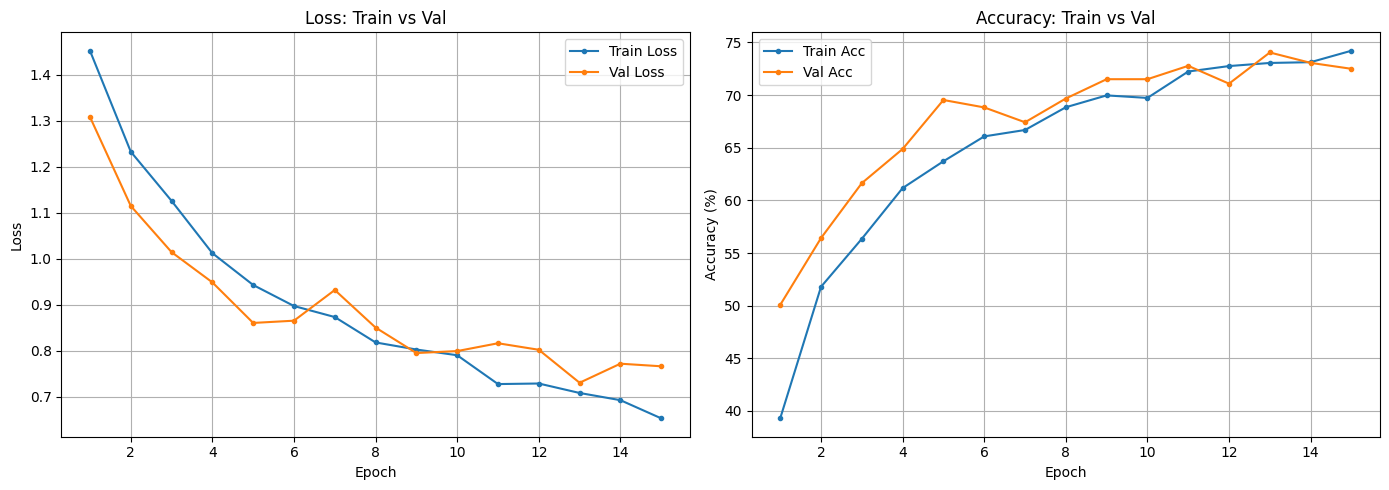

In [ ]:
import matplotlib.pyplot as plt


epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history['val_loss'],   label='Val Loss',   marker='.')


plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: Train vs Val')
plt.legend()
plt.grid(True)

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history['val_acc'],   label='Val Acc',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy: Train vs Val')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##Graficas

En las gráficas podemos observar el historial de pérdidas y presiciones.

En la gráfica de perdida se ve que la tendencia es disminuir los valores salvo en alguna época donde este sube,también podemos ver que el entrenamiento empieza en las primeras épocas con una mayor perdida pero al final llega a ser menor que el de la validación.

En la gráfica de precisión observamos que los porcentajes suben pero son un poco mas variables que las perdidas teniendo épocas donde sube y baja.

##Matrices de confusión

A continuación vemos las matrices de confusión del entrenamiento, test  y validación que nos dejan   analizar con mayor detalle el comportamiento con cada una de las clases y asi ver que clase le cuesta más clasificar

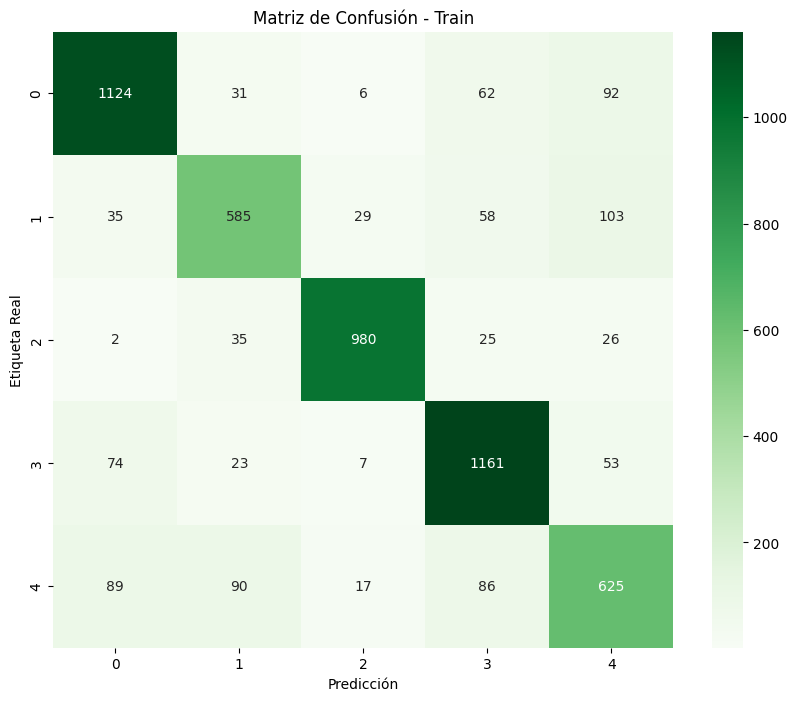

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Train')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

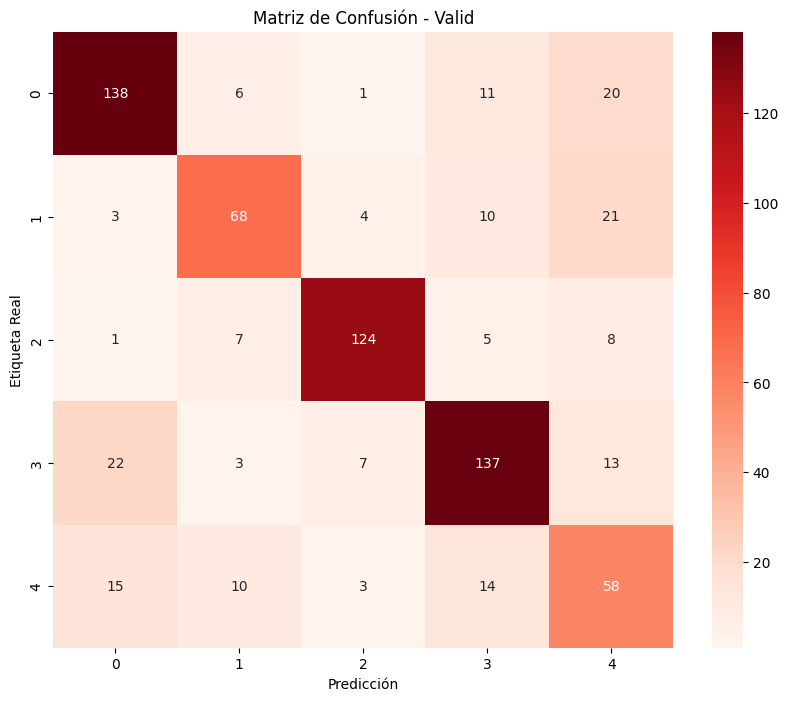

In [ ]:
net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión - Valid')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

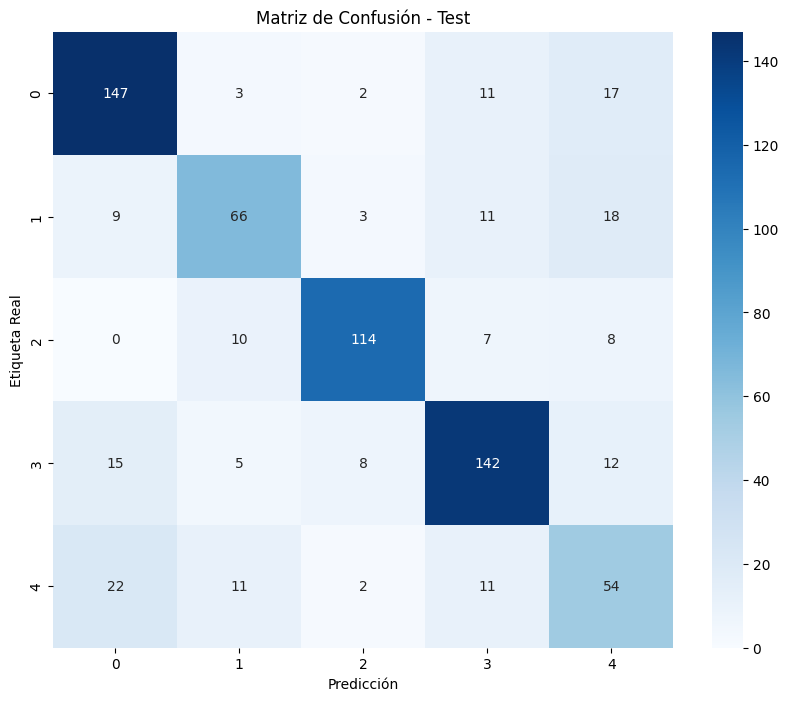

In [ ]:

net.eval()

all_preds_train = []
all_labels_train = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_train = confusion_matrix(all_labels_train, all_preds_train)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

##Resultado de la visualización de las matrices de confusión

Las matrices de confusión revelan que el modelo tiene más dificultades con la segunda y quinta clase. Esto era predecible debido al desbalanceo del dataset: estas clases contaban con menos imagenes que el resto, lo que dificulta que la red aprenda a classificarlas correctamente